# Model za procjenu potrebnog vremena učenja
### Treniranje i vrednovanje

Ova bilježnica nastavlja se na pripremljene podatke (`podaci_za_model.csv`) iz bilježnice s
analizom. Cilj je izgraditi i vrednovati model strojnog učenja koji na temelju svojstava
obveze procjenjuje potreban broj sati učenja. Poseban je naglasak na poštenom vrednovanju
koje uzima u obzir grupnu strukturu podataka.

## 1. Učitavanje podataka i priprema

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv("podaci_za_model.csv")
print("Oblik skupa:", df.shape)
df.head()

Oblik skupa: (301, 17)


,ects_kolegija,tezina_kolegija,postotak_ocjene,tezina_obveze,sigurnost_prije,tip_Ispit,tip_Kolokvij,tip_Labos,tip_Mini test,tip_Ostalo,tip_Projekt,tip_Seminar,tip_Usmeni ispit,tip_Zadaće,sati_ucenja,sati_ucenja_log,id_ispitanika
0,5.0,8.0,10.0,3.0,1.0,False,False,False,True,False,False,False,False,False,25.0,3.258097,5
1,5.0,8.0,90.0,9.0,4.0,True,False,False,False,False,False,False,False,False,100.0,4.615121,5
2,5.0,7.0,50.0,6.0,1.0,False,True,False,False,False,False,False,False,False,70.0,4.262680,5
3,5.0,7.0,50.0,7.0,3.0,False,True,False,False,False,False,False,False,False,37.0,3.637586,5
4,5.0,4.0,100.0,5.0,3.0,True,False,False,False,False,False,False,False,False,21.0,3.091042,5


### 1.1. Definiranje značajki, cilja i grupa

Ulazne značajke su svojstva obveze i kolegija (uključujući *one-hot* kodiranu vrstu obveze).
Ciljna varijabla jest **logaritam sati učenja** (`sati_ucenja_log`), na kojem se model
trenira zbog ranije utvrđene zakošenosti. Stupac `id_ispitanika` služi kao oznaka grupe za
grupno vrednovanje i nije ulazna značajka.

In [3]:
izostavi = ["sati_ucenja", "sati_ucenja_log", "id_ispitanika"]
znacajke = [c for c in df.columns if c not in izostavi]

X = df[znacajke].copy()
y = df["sati_ucenja"]            # izvorne vrijednosti (za tumačenje greške u satima)
y_log = df["sati_ucenja_log"]    # log-vrijednosti (za treniranje)
groups = df["id_ispitanika"]

# Nedostajuće vrijednosti popunjavamo medijanom značajke
X = X.fillna(X.median())

print("Broj značajki:", X.shape[1])
print("Broj obaveza:", X.shape[0])
print("Broj ispitanika (grupa):", groups.nunique())

Broj značajki: 14
Broj obaveza: 301
Broj ispitanika (grupa): 56


## 2. Vrednovanje s obzirom na grupnu strukturu

Budući da je svaki ispitanik unio više obaveza, obveze istoga ispitanika nisu međusobno
nezavisne. Kada bi se podaci dijelili nasumično, obveze istog ispitanika mogle bi se naći i
u skupu za treniranje i u skupu za vrednovanje, čime bi model mogao „prepoznati" ispitanika
i djelovati bolje nego što uistinu jest (curenje informacija kroz grupe).

Zbog toga se za vrednovanje koristi **grupna unakrsna validacija** (`GroupKFold`), koja
osigurava da svi zapisi jednog ispitanika pripadaju istom podskupu. Time se procjenjuje
uspješnost modela na ispitanicima koje pri treniranju nije vidio, što odgovara stvarnoj
namjeni sustava.

In [4]:
gkf = GroupKFold(n_splits=5)

# Provjera: nijedan ispitanik ne smije biti u train i test istovremeno
for i, (tr, te) in enumerate(gkf.split(X, y_log, groups=groups), 1):
    preklap = set(groups.iloc[tr]) & set(groups.iloc[te])
    print(f"Preklop {i}. podjela: {len(preklap)} ispitanika u oba skupa "
          f"(test: {groups.iloc[te].nunique()} ispitanika, {len(te)} obaveza)")

Preklop 1. podjela: 0 ispitanika u oba skupa (test: 11 ispitanika, 60 obaveza)
Preklop 2. podjela: 0 ispitanika u oba skupa (test: 11 ispitanika, 60 obaveza)
Preklop 3. podjela: 0 ispitanika u oba skupa (test: 12 ispitanika, 63 obaveza)
Preklop 4. podjela: 0 ispitanika u oba skupa (test: 11 ispitanika, 59 obaveza)
Preklop 5. podjela: 0 ispitanika u oba skupa (test: 11 ispitanika, 59 obaveza)


## 3. Usporedba modela

Uspoređuju se četiri pristupa:

- **Osnovica** — jednostavan model koji uvijek predviđa medijan (referentna vrijednost),
- **linearna regresija** — osnovni linearni model,
- **Random Forest** — ansambl stabala odluke,
- **Gradient Boosting** — postupno građeni ansambl stabala.

Svi se modeli treniraju na logaritamskoj ciljnoj varijabli, a predviđanja se pri
vrednovanju vraćaju na izvornu skalu (sate) kako bi pogreška bila izražena u satima.
Koriste se dvije mjere: **MAE** (prosječno apsolutno odstupanje u satima; manje je bolje) i
**R²** (udio objašnjene varijance; bliže 1 je bolje).

In [5]:
modeli = {
    "Osnovica (medijan)": DummyRegressor(strategy="median"),
    "Linearna regresija": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

rezultati = []
for naziv, model in modeli.items():
    pred_log = cross_val_predict(model, X, y_log, cv=gkf, groups=groups)
    pred = np.expm1(pred_log)                 # vraćanje na sate
    pred = np.clip(pred, 0, None)             # bez negativnih sati
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    rezultati.append({"Model": naziv, "MAE (h)": round(mae, 1), "R²": round(r2, 2)})

rez_df = pd.DataFrame(rezultati)
rez_df

,Model,MAE (h),R²
0,Osnovica (medijan),36.3,-0.09
1,Linearna regresija,29.3,0.18
2,Random Forest,30.9,0.16
3,Gradient Boosting,31.3,0.18


**Tumačenje.** Osnovica koja uvijek predviđa medijan ima negativan R², što znači da je
lošija od jednostavnog prosjeka. Svi ostali modeli nadmašuju osnovicu i objašnjavaju otprilike
petinu varijance u satima učenja. Gradient Boosting postiže najbolji rezultat, uz najmanju
pogrešku i najviši R². Umjerene vrijednosti očekivane su: kako je pokazano u analizi, sam
ispitanik objašnjava znatan dio varijance, a mnogi činitelji koji utječu na vrijeme učenja
(predznanje, način učenja, koncentracija) anketom nisu obuhvaćeni.

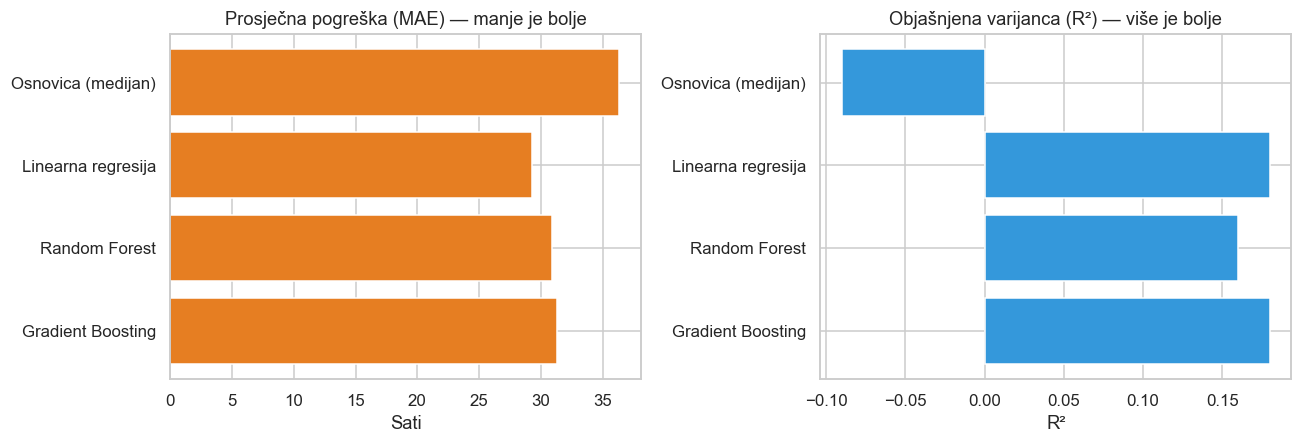

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].barh(rez_df["Model"], rez_df["MAE (h)"], color="#e67e22")
axes[0].set(title="Prosječna pogreška (MAE) — manje je bolje", xlabel="Sati")
axes[0].invert_yaxis()
axes[1].barh(rez_df["Model"], rez_df["R²"], color="#3498db")
axes[1].set(title="Objašnjena varijanca (R²) — više je bolje", xlabel="R²")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 4. Optimizacija hiperparametara

Za najbolji model iz prethodne usporedbe (Gradient Boosting) provodi se optimizacija hiperparametara metodom pretrage po rešetki (GridSearchCV). Pretražuju se kombinacije broja stabala, dubine i stope učenja, uz istu grupnu unakrsnu validaciju. Cilj je pronaći postavke s najmanjom pogreškom.

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
}
grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                    param_grid, cv=gkf, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X, y_log, groups=groups)
print("Najbolji hiperparametri:", grid.best_params_)

Najbolji hiperparametri: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}


In [8]:
# Usporedba zadanih i optimiziranih postavki
for naziv, model in [("Zadane postavke", GradientBoostingRegressor(random_state=42)),
                     ("Optimizirano", grid.best_estimator_)]:
    pl = cross_val_predict(model, X, y_log, cv=gkf, groups=groups)
    p_ = np.clip(np.expm1(pl), 0, None)
    print(f"{naziv:18} MAE = {mean_absolute_error(y, p_):.1f} h | R² = {r2_score(y, p_):.3f}")

Zadane postavke    MAE = 31.3 h | R² = 0.178
Optimizirano       MAE = 29.3 h | R² = 0.170


**Tumačenje.** Optimizacijom je pronađena kombinacija sa sporijom stopom učenja i dubljim stablima, koja daje blago bolji rezultat od zadanih postavki (viši R², nešto manja pogreška). Umjereno poboljšanje pokazuje da glavno ograničenje točnosti nije u postavkama modela, nego u samim podacima. U nastavku se koristi optimizirani model.

## 5. Vrednovanje konačnog modela

Odabrani model (Gradient Boosting) detaljnije se vrednuje usporedbom stvarnih i predviđenih
vrijednosti dobivenih grupnom unakrsnom validacijom.

Gradient Boosting — MAE: 29.3 h | R²: 0.17


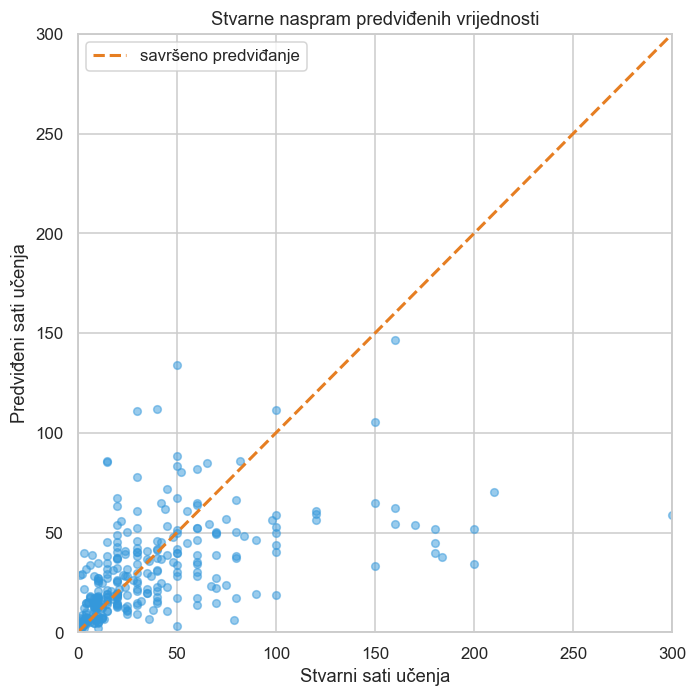

In [9]:
najbolji = grid.best_estimator_   # optimizirani model
pred_log = cross_val_predict(najbolji, X, y_log, cv=gkf, groups=groups)
pred = np.clip(np.expm1(pred_log), 0, None)

mae = mean_absolute_error(y, pred)
r2 = r2_score(y, pred)
print(f"Gradient Boosting — MAE: {mae:.1f} h | R²: {r2:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y, pred, alpha=0.5, color="#3498db", s=25)
lim = [0, min(300, y.max())]
ax.plot(lim, lim, "--", color="#e67e22", lw=2, label="savršeno predviđanje")
ax.set(title="Stvarne naspram predviđenih vrijednosti",
       xlabel="Stvarni sati učenja", ylabel="Predviđeni sati učenja",
       xlim=lim, ylim=lim)
ax.legend()
plt.tight_layout(); plt.show()

**Tumačenje.** Točke se grupiraju oko dijagonale, no uz osjetan rasap, osobito za obveze s
velikim brojem sati koje model sustavno podcjenjuje. To je posljedica malog broja takvih
primjera i njihove velike varijabilnosti. Model najbolje procjenjuje obveze prosječnog
opsega, koje čine većinu podataka.

## 6. Važnost značajki

Za odabrani se model prikazuje važnost pojedinih značajki, odnosno koliko svaka značajka
doprinosi predviđanju. Model se za ovu analizu trenira na cijelom skupu podataka.

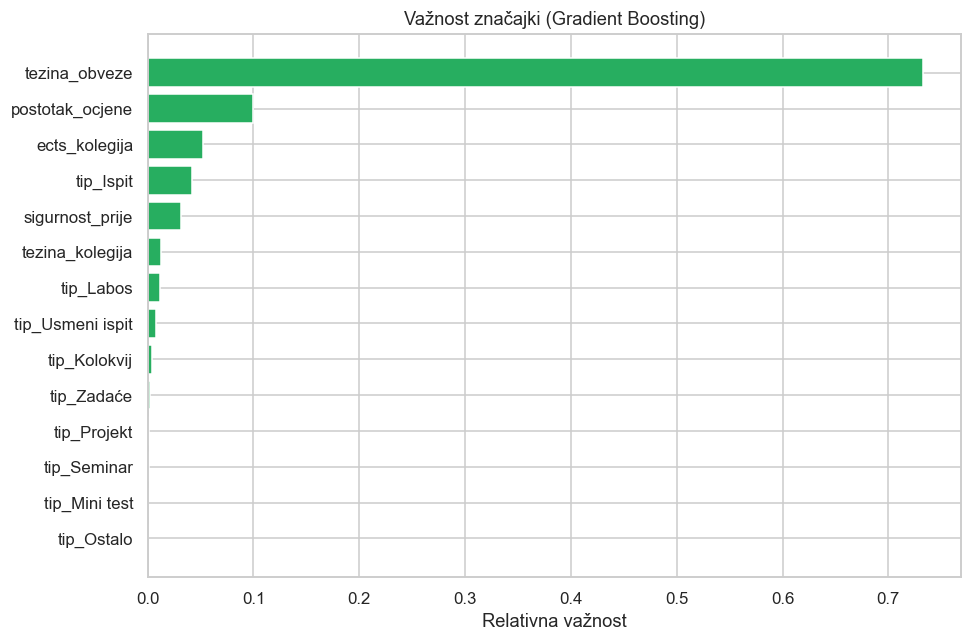

Najvažnije značajke:
tezina_obveze      0.732
postotak_ocjene    0.099
ects_kolegija      0.053
tip_Ispit          0.042
sigurnost_prije    0.031
tezina_kolegija    0.013
dtype: float64


In [10]:
najbolji.fit(X, y_log)
vaznost = (pd.Series(najbolji.feature_importances_, index=X.columns)
           .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(vaznost.index, vaznost.values, color="#27ae60")
ax.set(title="Važnost značajki (Gradient Boosting)", xlabel="Relativna važnost")
plt.tight_layout(); plt.show()

print("Najvažnije značajke:")
print(vaznost.sort_values(ascending=False).head(6).round(3))

**Tumačenje.** Rezultati potvrđuju nalaze iz analize: težina obveze i pripadnost obveze
tipu ispita među najutjecajnijim su značajkama, dok samopouzdanje ima malen doprinos. Time se
pokazuje da model najviše oslonac nalazi u procjeni zahtjevnosti obveze i njezinoj vrsti, što
je u skladu s očekivanjima.

## 7. Primjer procjene za novu obvezu

Za ilustraciju praktične primjene, model se primjenjuje na ručno zadanu novu obvezu.

In [11]:
# Primjer: spomeni obveza tipa "Ispit", ECTS 6, težina kolegija 7,
# udio bodova 50%, težina obveze 8, samopouzdanje 4
primjer = pd.DataFrame([{c: 0 for c in X.columns}])
primjer["ects_kolegija"] = 6
primjer["tezina_kolegija"] = 7
primjer["postotak_ocjene"] = 50
primjer["tezina_obveze"] = 8
primjer["sigurnost_prije"] = 4
if "tip_Ispit" in primjer.columns:
    primjer["tip_Ispit"] = 1

procjena = np.expm1(najbolji.predict(primjer))[0]
print(f"Procijenjeno vrijeme učenja za zadanu obvezu: {procjena:.0f} sati")

Procijenjeno vrijeme učenja za zadanu obvezu: 52 sati


In [12]:
# Primjer: mini test, ECTS 5, težina kolegija 5,
# udio bodova 1%, težina obveze 3, samopouzdanje 6
primjer = pd.DataFrame([{c: 0 for c in X.columns}])
primjer["ects_kolegija"] = 5
primjer["tezina_kolegija"] = 5
primjer["postotak_ocjene"] = 1
primjer["tezina_obveze"] = 3          # niska težina za lagani mini test
primjer["sigurnost_prije"] = 6
if "tip_Mini test" in primjer.columns:   # TOČAN naziv: velika slova + razmak
    primjer["tip_Mini test"] = 1

procjena = np.expm1(najbolji.predict(primjer))[0]
print(f"Procijenjeno vrijeme učenja za zadanu obvezu: {procjena:.0f} sati")

Procijenjeno vrijeme učenja za zadanu obvezu: 4 sati


---
## Sažetak

Izgrađen je model za procjenu potrebnog vremena učenja na temelju svojstava obveze i
kolegija. Zbog grupne strukture podataka (više obaveza po ispitaniku) primijenjena je grupna
unakrsna validacija, koja daje poštenu procjenu uspješnosti na novim ispitanicima. Najbolji
rezultat postiže model Gradient Boosting, uz umjerenu točnost očekivanu s obzirom na
subjektivnu prirodu procjene vremena učenja i ograničenja prikupljenih podataka. Najutjecajnije
značajke su težina i vrsta obveze. Dobiveni model predstavlja polazište koje se u budućnosti
može unaprijediti većim i raznovrsnijim skupom podataka te dodatnim značajkama.

## 8. Spremanje modela za primjenu u aplikaciji

Konačni (optimizirani) model trenira se na cijelom skupu podataka i sprema u datoteku zajedno s popisom značajki. Time se model može učitati u aplikaciji bez ponovnog treniranja. Uz model se sprema i redoslijed značajki jer ulazni podaci pri predviđanju moraju imati identičan oblik kao pri treniranju.

In [13]:
import joblib

# Treniraj konačni model na SVIM podacima
konacni_model = grid.best_estimator_
konacni_model.fit(X, y_log)

# Spremi model + popis značajki (redoslijed je bitan!)
paket = {
    "model": konacni_model,
    "znacajke": list(X.columns),   # točan redoslijed stupaca
    "log_cilj": True,              # model predviđa log(1+sati), treba expm1
}
joblib.dump(paket, "model.pkl")
print("Model spremljen u model.pkl")
print("Broj značajki:", len(paket["znacajke"]))
print("Značajke:", paket["znacajke"])

Model spremljen u model.pkl
Broj značajki: 14
Značajke: ['ects_kolegija', 'tezina_kolegija', 'postotak_ocjene', 'tezina_obveze', 'sigurnost_prije', 'tip_Ispit', 'tip_Kolokvij', 'tip_Labos', 'tip_Mini test', 'tip_Ostalo', 'tip_Projekt', 'tip_Seminar', 'tip_Usmeni ispit', 'tip_Zadaće']


Datoteka  sada sadrži istrenirani model i sve potrebno za njegovu primjenu. Tu datoteku treba kopirati u mapu aplikacije kako bi je aplikacija mogla učitati.